In [ ]:
import pandas as pd

# I imported pandas for data handling
# I loaded the dataset from the CSV file

df = pd.read_csv("bank-full.csv", sep=";")


In [ ]:
# I cleaned the column names by removing extra spaces from the columns.

df.columns = df.columns.str.strip()


In [ ]:
# I renamed the columns to make them more clear and meaningful way so that will be easy for me
df = df.rename(columns={
    "y": "target",
    "job": "job_type",
    "marital": "marital_status",
    "education": "education_level",
    "default": "credit_default",
    "housing": "housing_loan",
    "loan": "personal_loan",
    "contact": "contact_type",
    "duration": "call_duration",
    "campaign": "contact_count",
    "pdays": "days_since_last_contact",
    "previous": "previous_contacts",
    "poutcome": "previous_campaign_outcome"
})


In [ ]:
# I checked the shape of the dataset

print("Dataset shape:", df.shape)


Dataset shape: (45211, 17)


In [ ]:
# I checked how many duplicate rows are there
print("Duplicate rows:", df.duplicated().sum())

# I removed the duplicate rows
df = df.drop_duplicates()

# I checked the shape again after removing duplicates
print("Shape after removing duplicates:", df.shape)


Duplicate rows: 0
Shape after removing duplicates: (45211, 17)


In [ ]:
# I checked null values in each column
print(df.isnull().sum())


age                          0
job_type                     0
marital_status               0
education_level              0
credit_default               0
balance                      0
housing_loan                 0
personal_loan                0
contact_type                 0
day                          0
month                        0
call_duration                0
contact_count                0
days_since_last_contact      0
previous_contacts            0
previous_campaign_outcome    0
target                       0
dtype: int64


In [ ]:
# I calculated the total number of null values

print("Total null values:", df.isnull().sum().sum())


Total null values: 0


In [ ]:
# I converted the target column into binary values

df["target"] = df["target"].map({"yes": 1, "no": 0})


In [ ]:
# I Dropped call duration to avoid data leakage
df = df.drop(columns=["call_duration"])


In [ ]:
# I checked the data types and overall dataset info

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   age                        45211 non-null  int64 
 1   job_type                   45211 non-null  object
 2   marital_status             45211 non-null  object
 3   education_level            45211 non-null  object
 4   credit_default             45211 non-null  object
 5   balance                    45211 non-null  int64 
 6   housing_loan               45211 non-null  object
 7   personal_loan              45211 non-null  object
 8   contact_type               45211 non-null  object
 9   day                        45211 non-null  int64 
 10  month                      45211 non-null  object
 11  contact_count              45211 non-null  int64 
 12  days_since_last_contact    45211 non-null  int64 
 13  previous_contacts          45211 non-null  int64 
 14  previo

In [ ]:
# I looked at the summary statistics of numerical columns

df.describe()


,age,balance,day,contact_count,days_since_last_contact,previous_contacts,target
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,2.763841,40.197828,0.580323,0.116985
std,10.618762,3044.765829,8.322476,3.098021,100.128746,2.303441,0.321406
min,18.000000,-8019.000000,1.000000,1.000000,-1.000000,0.000000,0.000000
25%,33.000000,72.000000,8.000000,1.000000,-1.000000,0.000000,0.000000
50%,39.000000,448.000000,16.000000,2.000000,-1.000000,0.000000,0.000000
75%,48.000000,1428.000000,21.000000,3.000000,-1.000000,0.000000,0.000000
max,95.000000,102127.000000,31.000000,63.000000,871.000000,275.000000,1.000000


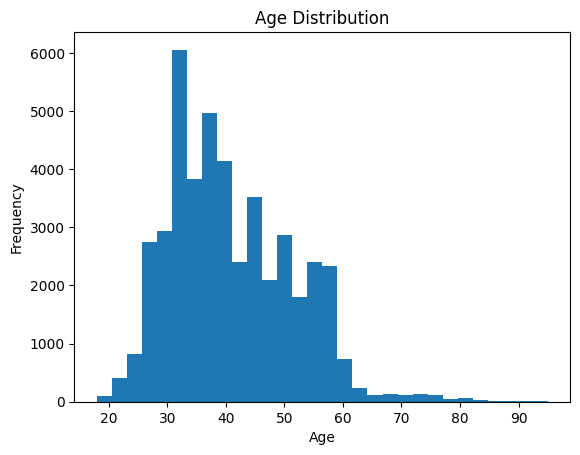

In [ ]:
import matplotlib.pyplot as plt

# I plotted the age distribution using a histogram

plt.hist(df["age"], bins=30)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# I checked the count of target classes
df["target"].value_counts()


,count
target,
0,39922
1,5289


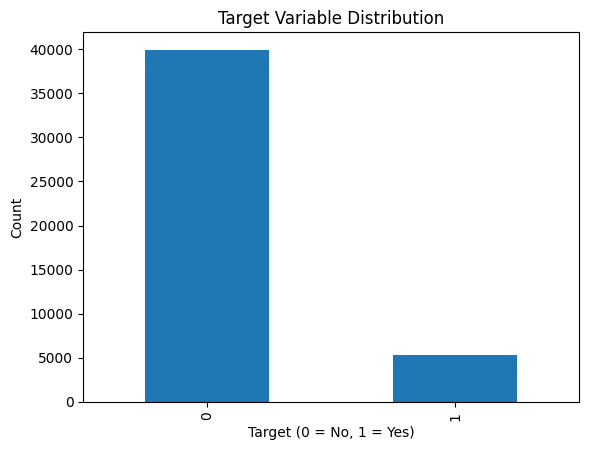

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1. Target variable distribution
# -------------------------------

# This is for the Count of subscription outcomes
df["target"].value_counts()

plt.figure()
# Using Bar plot to show class imbalance
df["target"].value_counts().plot(kind="bar")
plt.xlabel("Target (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.title("Target Variable Distribution")
plt.show()


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


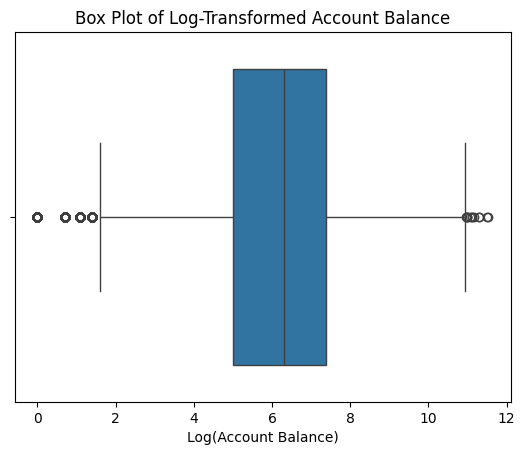

In [ ]:
# -------------------------------
# 3. Box plot for outliers (Balance)
# -------------------------------
# I created a box plot to check outliers in balance

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
# I applied log transformation to balance (add 1 to avoid log(0))
sns.boxplot(x=np.log1p(df["balance"]))
plt.xlabel("Log(Account Balance)")
plt.title("Box Plot of Log-Transformed Account Balance")
plt.show()


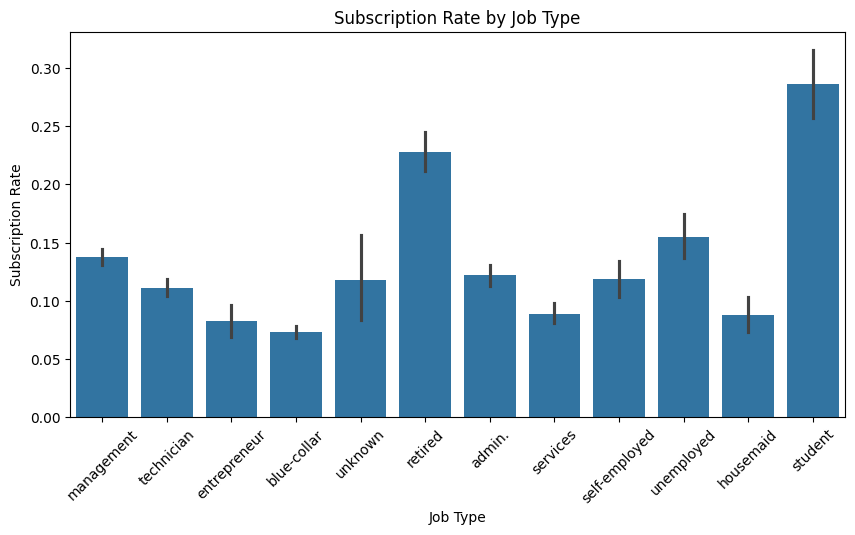

In [ ]:
# -------------------------------
# 4. Job type vs subscription rate
# -------------------------------

plt.figure(figsize=(10,5))
# I created a bar plot to compare subscription rate by job
sns.barplot(
    x="job_type",
    y="target",
    data=df,
    estimator=lambda x: sum(x) / len(x)
)
plt.xticks(rotation=45)
plt.xlabel("Job Type")
plt.ylabel("Subscription Rate")
plt.title("Subscription Rate by Job Type")
plt.show()

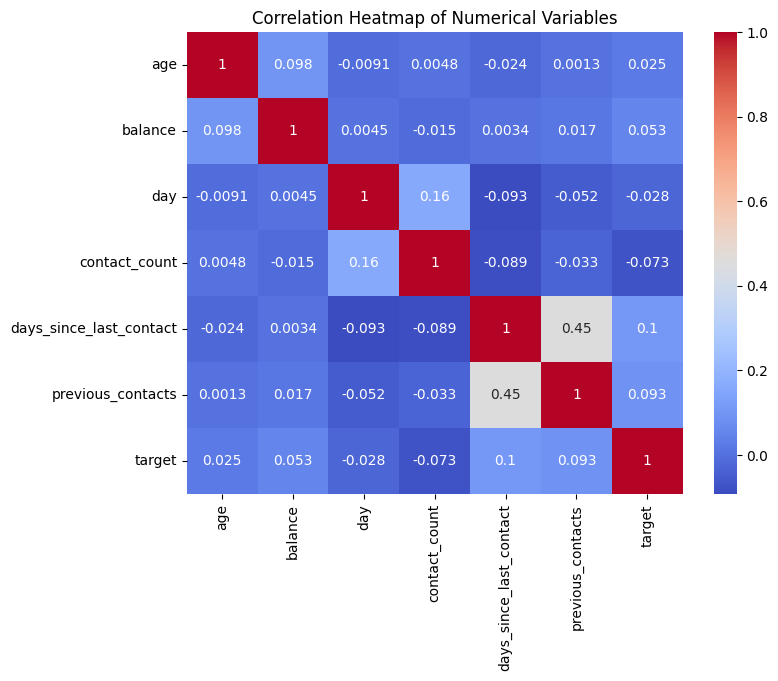

In [ ]:
# -------------------------------
# 5. Correlation heatmap
# -------------------------------

plt.figure(figsize=(8,6))
# I Selected only numerical columns for correlation
numeric_cols = df.select_dtypes(include=["int64", "float64"])

# I created a correlation heatmap to see relationships
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()